<a href="https://colab.research.google.com/github/AntoonGoderis/Deep-Learning/blob/Antoon/Assignment_2_GroupA_1_Goderis_Mertens_Hereman_VanCaeneghem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import ast

import numpy as np
import pandas as pd
import cv2
from scipy.optimize import curve_fit

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import SGD, AdamW

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.regularizers import l2
from keras.utils import to_categorical
!pip install keras-tuner

import keras_tuner as kt

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import zipfile

import keras

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

from tensorflow.keras.callbacks import ReduceLROnPlateau


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/alvarobartt/simpsons-mnist.git

Cloning into 'simpsons-mnist'...
remote: Enumerating objects: 20148, done.
remote: Counting objects: 100% (20148/20148), done.
remote: Compressing objects: 100% (20032/20032), done.
remote: Total 20148 (delta 218), reused 20022 (delta 111), pack-reused 0 (from 0)
Receiving objects: 100% (20148/20148), 24.79 MiB | 37.27 MiB/s, done.
Resolving deltas: 100% (218/218), done.


In [ ]:

dataset_path = "simpsons-mnist/dataset/rgb/train/"
test_path = "simpsons-mnist/dataset/rgb/test/"


image_data = []
test_data = []


for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            image_data.append((os.path.join(class_path, img_name), class_name))

df_train = pd.DataFrame(image_data, columns=["image_path", "label"])
print(df_train.head())

for class_name in os.listdir(test_path):

    class_path = os.path.join(test_path, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            test_data.append((os.path.join(class_path, img_name), class_name))


df_test = pd.DataFrame(test_data, columns=["image_path", "label"])
print(df_test.head())



                                          image_path         label
0  simpsons-mnist/dataset/rgb/train/lisa_simpson/...  lisa_simpson
1  simpsons-mnist/dataset/rgb/train/lisa_simpson/...  lisa_simpson
2  simpsons-mnist/dataset/rgb/train/lisa_simpson/...  lisa_simpson
3  simpsons-mnist/dataset/rgb/train/lisa_simpson/...  lisa_simpson
4  simpsons-mnist/dataset/rgb/train/lisa_simpson/...  lisa_simpson
                                          image_path         label
0  simpsons-mnist/dataset/rgb/test/lisa_simpson/p...  lisa_simpson
1  simpsons-mnist/dataset/rgb/test/lisa_simpson/p...  lisa_simpson
2  simpsons-mnist/dataset/rgb/test/lisa_simpson/p...  lisa_simpson
3  simpsons-mnist/dataset/rgb/test/lisa_simpson/p...  lisa_simpson
4  simpsons-mnist/dataset/rgb/test/lisa_simpson/p...  lisa_simpson


In [ ]:

def load_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
    img = img / 255.0
    return img


df_train["image_array"] = df_train["image_path"].apply(lambda x: load_image(x))

df_test["image_array"] = df_test["image_path"].apply(lambda x: load_image(x))




sample_img = df_train["image_array"][0]
print(sample_img.shape)


(28, 28, 3)


In [ ]:
num_classes = df_train.label.nunique()
print(num_classes)


10


In [ ]:


batch_size = 64
epochs = 250



label_encoder = LabelEncoder()
df_train["label_encoded"] = label_encoder.fit_transform(df_train["label"])
df_test["label_encoded"] = label_encoder.transform(df_test["label"])




X_train_valid = np.stack(df_train["image_array"].values)


y_train_valid = to_categorical(df_train["label_encoded"], num_classes=num_classes)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.3, random_state=42)

X_test = np.stack(df_test["image_array"].values)
y_test = to_categorical(df_test["label_encoded"], num_classes=num_classes)




print(X_train_valid.shape)
print(y_train_valid.shape)



(8000, 28, 28, 3)
(8000, 10)


In [ ]:
X_train_resized = np.array([tf.image.resize(img, [64, 64], method="lanczos3") for img in X_train])
X_valid_resized = np.array([tf.image.resize(img, [64, 64], method="lanczos3") for img in X_valid])

#PRE TRAINED MODELS


##RESNET50

We use ResNet50 as the base model, pretrained on ImageNet to leverage learned features. The top layer is removed (include_top=False) so we can add our own classifier. To balance transfer learning and fine-tuning, we freeze all but the last 20 layers, allowing the deeper layers to adapt to our specific dataset. Aditionally we use datagenerators to keep the processing of our images need and organised. Lastly we decided to add data augmentation like "zoom_range", "shear_range", "brightness_range" to make the model more robust.

First we tried to run the pre trained with images that are 32x32, since this is minimum resolution resnet50 accepts.

In [ ]:
dataset_path = "simpsons-mnist-master/dataset/rgb/train/"
test_path = "simpsons-mnist/dataset/rgb/test/"


IMG_SIZE = (32, 32)
BATCH_SIZE = 64


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=40,
    zoom_range=0.3,
    shear_range=0.3,
    width_shift_range=0.3,
    height_shift_range=0.3,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)


train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)


val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)



Found 6400 images belonging to 10 classes.
Found 1600 images belonging to 10 classes.


###32x32 Model

As seen below running resnet50 on images with a resolution of 32x32 didnt yield good results. We assumed that this probably because resnet50 is trained on 224x224 images and thus has difficulties distinguishing features on smaller images. We came to an important conclusion that it perhaps might be worth exploring what happens when we resize the images even further. In the end we trained 4 different models in total, on image sizes of 32x32, 64x64, 128x128 and 224x224.

In [ ]:

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    verbose=1,
    callbacks=[reduce_lr, early_stopping]
)

Epoch 1/200
100/100 [==============================] - 108s 1s/step - loss: 5.3821 - accuracy: 0.1281 - val_loss: 2.9751 - val_accuracy: 0.1881 - lr: 1.0000e-04
Epoch 2/200
100/100 [==============================] - 97s 968ms/step - loss: 3.2334 - accuracy: 0.1578 - val_loss: 2.7198 - val_accuracy: 0.1850 - lr: 1.0000e-04
Epoch 3/200
100/100 [==============================] - 98s 977ms/step - loss: 2.8466 - accuracy: 0.1755 - val_loss: 2.6591 - val_accuracy: 0.2219 - lr: 1.0000e-04
Epoch 4/200
100/100 [==============================] - 97s 968ms/step - loss: 2.7470 - accuracy: 0.1914 - val_loss: 2.6034 - val_accuracy: 0.2469 - lr: 1.0000e-04
Epoch 5/200
100/100 [==============================] - 98s 973ms/step - loss: 2.6913 - accuracy: 0.2008 - val_loss: 2.5947 - val_accuracy: 0.2475 - lr: 1.0000e-04
Epoch 6/200
100/100 [==============================] - 92s 922ms/step - loss: 2.6435 - accuracy: 0.2186 - val_loss: 2.5759 - val_accuracy: 0.2469 - lr: 1.0000e-04
Epoch 7/200
100/100 [===

To get a visual representation of our model we plotted the validation loss, train loss , validation accuracy and train accuracy.

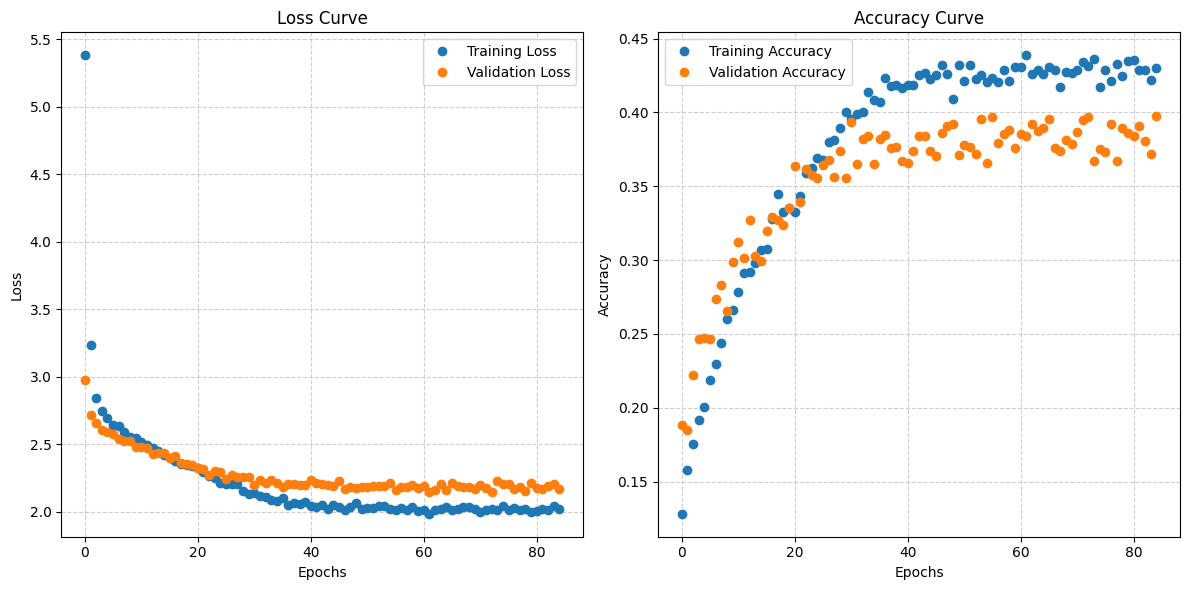

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], marker='o', linestyle='none', label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], marker='o', linestyle='none', label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], marker='o', linestyle='none', label='Training Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], marker='o', linestyle='none', label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

###64x64 Model

In the code below, we ran the model with 64x64 images and we can already see a significant improvement compared to the 32x32 images, the validation accuarcy increased with almost 20% whereas the validation loss decreased by around 0.4. This increase in performance is the main reason why we tried even higher resizing of the images, even though it gets computationally expensive.


In [ ]:

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    verbose=1,
    callbacks=[reduce_lr, early_stopping]
)

Epoch 1/200
100/100 [==============================] - 141s 1s/step - loss: 3.7030 - accuracy: 0.1547 - val_loss: 2.6840 - val_accuracy: 0.2062 - lr: 1.0000e-04
Epoch 2/200
100/100 [==============================] - 134s 1s/step - loss: 2.7594 - accuracy: 0.2106 - val_loss: 2.5103 - val_accuracy: 0.3019 - lr: 1.0000e-04
Epoch 3/200
100/100 [==============================] - 136s 1s/step - loss: 2.5594 - accuracy: 0.2716 - val_loss: 2.3802 - val_accuracy: 0.3462 - lr: 1.0000e-04
Epoch 4/200
100/100 [==============================] - 139s 1s/step - loss: 2.4305 - accuracy: 0.3159 - val_loss: 2.3402 - val_accuracy: 0.3475 - lr: 1.0000e-04
Epoch 5/200
100/100 [==============================] - 138s 1s/step - loss: 2.3369 - accuracy: 0.3498 - val_loss: 2.2552 - val_accuracy: 0.3981 - lr: 1.0000e-04
Epoch 6/200
100/100 [==============================] - 137s 1s/step - loss: 2.2328 - accuracy: 0.3919 - val_loss: 2.1860 - val_accuracy: 0.4256 - lr: 1.0000e-04
Epoch 7/200
100/100 [=============

We plotted the validation loss, train loss , validation accuracy and train accuracy of our 64x64 model.

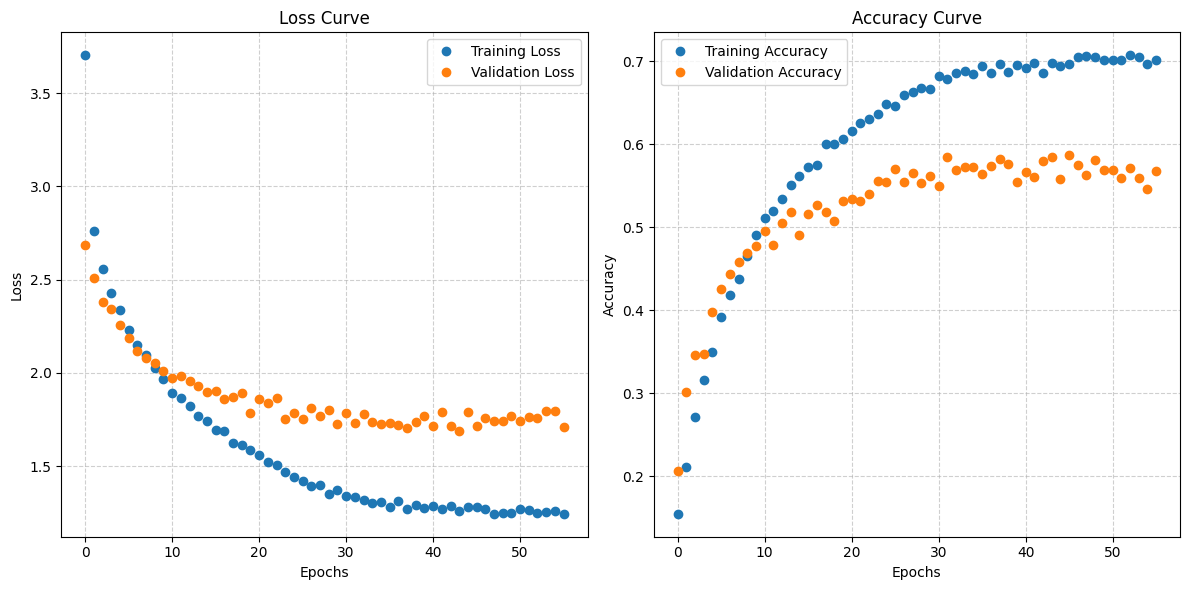

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], marker='o', linestyle='none', label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], marker='o', linestyle='none', label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], marker='o', linestyle='none', label='Training Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], marker='o', linestyle='none', label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 128x128 Model

The improvements dont seem to stop at 64x64 since our accuracy increased even further with the 128x128 model. We see an almost 15% improvement on validation accuracy and a decrease of the validation loss with around 0.4.

In [ ]:

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    verbose=1,
    callbacks=[reduce_lr, early_stopping]
)

Epoch 1/200
100/100 [==============================] - 229s 2s/step - loss: 3.0660 - accuracy: 0.1747 - val_loss: 2.4263 - val_accuracy: 0.3306 - lr: 1.0000e-04
Epoch 2/200
100/100 [==============================] - 227s 2s/step - loss: 2.3296 - accuracy: 0.3555 - val_loss: 2.0966 - val_accuracy: 0.4669 - lr: 1.0000e-04
Epoch 3/200
100/100 [==============================] - 221s 2s/step - loss: 2.0085 - accuracy: 0.4802 - val_loss: 1.9725 - val_accuracy: 0.5225 - lr: 1.0000e-04
Epoch 4/200
100/100 [==============================] - 224s 2s/step - loss: 1.7838 - accuracy: 0.5634 - val_loss: 1.7586 - val_accuracy: 0.5781 - lr: 1.0000e-04
Epoch 5/200
100/100 [==============================] - 219s 2s/step - loss: 1.6602 - accuracy: 0.5948 - val_loss: 1.6814 - val_accuracy: 0.5931 - lr: 1.0000e-04
Epoch 6/200
100/100 [==============================] - 228s 2s/step - loss: 1.5242 - accuracy: 0.6434 - val_loss: 1.6369 - val_accuracy: 0.6225 - lr: 1.0000e-04
Epoch 7/200
100/100 [=============

We also plot this model to get a better visual interpretation.

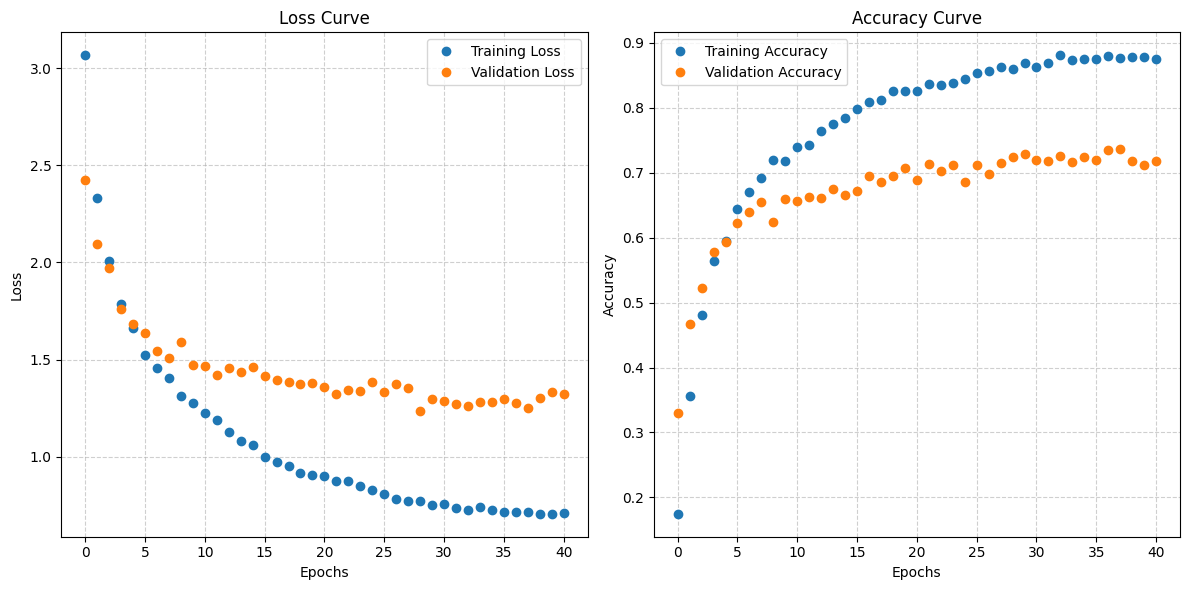

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], marker='o', linestyle='none', label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], marker='o', linestyle='none', label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], marker='o', linestyle='none', label='Training Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], marker='o', linestyle='none', label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

###224x224 Model


We continue to see improvement even though not as big as before. Our validation accuarcy went up by 8% and our validation loss decreased by 0.3. Since it looks like the improvements are diminishing and the training time is ramping up, we decided not try any further resizing.

In [ ]:

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    verbose=1,
    callbacks=[reduce_lr, early_stopping]
)

Epoch 1/200
100/100 [==============================] - 534s 5s/step - loss: 2.7202 - accuracy: 0.2350 - val_loss: 2.3160 - val_accuracy: 0.3844 - lr: 1.0000e-04
Epoch 2/200
100/100 [==============================] - 538s 5s/step - loss: 1.9935 - accuracy: 0.4814 - val_loss: 1.8464 - val_accuracy: 0.5525 - lr: 1.0000e-04
Epoch 3/200
100/100 [==============================] - 535s 5s/step - loss: 1.6041 - accuracy: 0.6252 - val_loss: 1.6937 - val_accuracy: 0.5806 - lr: 1.0000e-04
Epoch 4/200
100/100 [==============================] - 534s 5s/step - loss: 1.4228 - accuracy: 0.6823 - val_loss: 1.5565 - val_accuracy: 0.6444 - lr: 1.0000e-04
Epoch 5/200
100/100 [==============================] - 536s 5s/step - loss: 1.3123 - accuracy: 0.7192 - val_loss: 1.3832 - val_accuracy: 0.6925 - lr: 1.0000e-04
Epoch 6/200
100/100 [==============================] - 535s 5s/step - loss: 1.2020 - accuracy: 0.7559 - val_loss: 1.4213 - val_accuracy: 0.6856 - lr: 1.0000e-04
Epoch 7/200
100/100 [=============

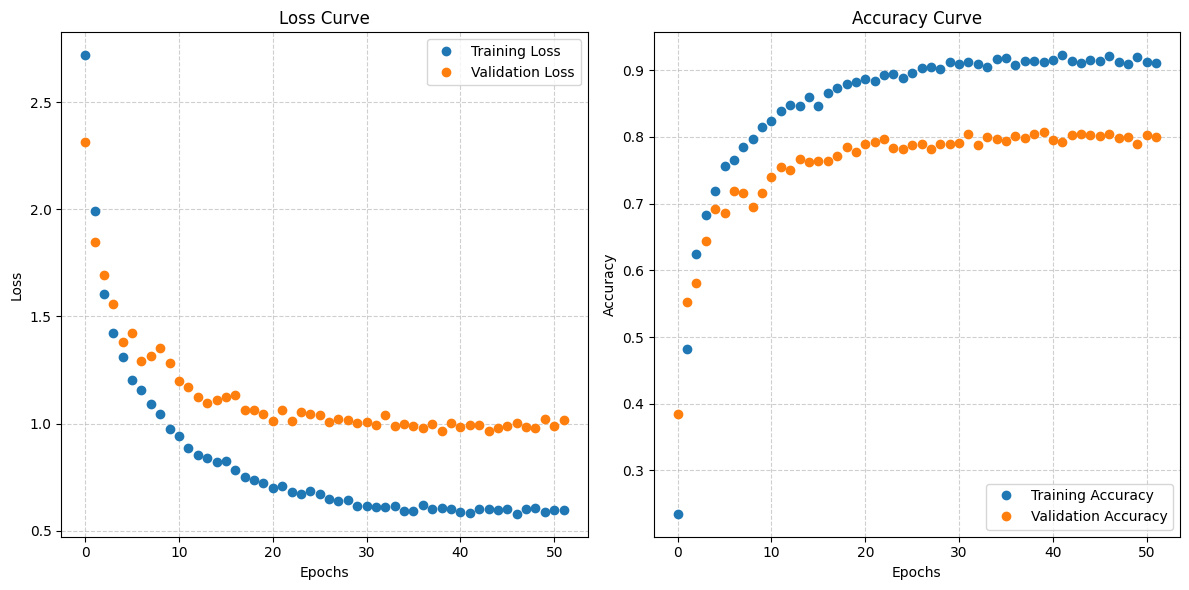

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], marker='o', linestyle='none', label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], marker='o', linestyle='none', label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], marker='o', linestyle='none', label='Training Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], marker='o', linestyle='none', label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##EFFICIENTNET B0

# Self-constructed models

## Models based on random search

We executed a series of random grid searches to explore the optimal CNN network architecture with each search informing the hyperparameter space of the next. We chose this approach given the execution time limitations on Google Colab. Each search ran 10 trials using a 3x3 kernel and  training for 100 epochs.

1.   Random search
  *   Hyperparameters
      * Layers : [1, 6]
      * Neurons per layer : [16, 513] (steps of 16)
      * L2 regularization : [0.0005, 0.001, 0.0015, 0.0025, 0.005, 0.01]
  *   Best model : validation accuracy 0.**8317**
      * Layers : 6
      * Neurons per layer : 320
      * L2 regularization : 0.001

2.   Random search
  *   Hyperparameters
      * Layers : [5, 14]
      * Neurons per layer : [256, 1025] (steps of 32)
      * L2 regularization : [0.0005, 0.001, 0.0015, 0.0025, 0.005, 0.01]
  *   Best model : validation accuracy 0.**8008**
      * Layers : 9
      * Neurons per layer : 320
      * L2 regularization : 0.001

3.   Random search,
  *   Hyperparameters
      * Layers : [6, 12]
      * Neurons per layer : [256, 360] (steps of 32)
      * L2 regularization : [0.0005, 0.001, 0.0015]
  *   Best model : validation accuracy 0.**8533**
      * Layers : 8
      * Neurons per layer : 256
      * L2 regularization : 0.001

4.   Random search
  *   Hyperparameters
      * Layers : 8
      * Neurons per layer : [200, 360] (steps of 16)
      * L2 regularization : [0.0005, 0.001, 0.0001]
      * Activation function : [Leaky Relu, Gelu]
  *   Best model : validation accuracy **0.9008**
      * Layers : 8
      * Neurons per layer : 344
      * L2 regularization : 0.0001
      * Activation function : Gelu

5.   Random search
  *   Hyperparameters
      * Layers : 8
      * Neurons per layer : [300, 400] (steps of 16)
      * L2 regularization : [0.00005, 0.00001, 0.0001]
  *   Best model : validation accuracy 0.**9129**
      * Layers : 8
      * Neurons per layer : 300
      * L2 regularization : 1e-05

6.   Random search exploring data augmentation
  *   Hyperparameters
	    * 	rotation_range: [10, 15, 20, 25]
	    * 	width_shift_range: [0.1, 0.15, 0.2]
	    * 	height_shift_range: [0.1, 0.15, 0.2]
	    * 	horizontal_flip: [True]
	    * 	zoom_range: [0.2]
	    * 	shear_range: [10, 15]
	    * 	brightness_range: [[0.5, 1.5], [0.7, 1.3]]
	    * channel_shift_range: [30]
  *   Best model : validation accuracy **0.9154**
  	  * rotation_range: [25]
	    * width_shift_range: [0.2]
	    * height_shift_range: [0.2]
	    * zoom_range: [0.2]
	    * horizontal_flip: [True]






After that, we tried to finetune the model by using more complex kernels for the inner layers like (5x5) and (7x7), but this did not improve validation accuracy.

Finally, given the experience in optimizing the pre-trained models, we retrained the best random search model to allow feeding the CNN images of 64x64 instead of 28x28 pixels. This further increased validation accuracy to **0.9563**.

The executed code for the random searches can be found as an appendix to the report (uploaded as a separate notebook).

# Random search model evaluation

Performance of the best model on the test data set can be reported as Test Loss: 0.4414 and Test Accuracy: 0.**9505**.

The confusion matrix identifies that the model sometimes predicts Bart when Lisa should be picked and equally predicts Burns when Skinner should be chosen and Lisa when Homer should be chosen.

In [11]:


from google.colab import drive
drive.mount('/content/drive')

import zipfile

# Replace 'path/to/your_file.zip' with the path to your zip file in Google Drive
zip_file_path = '/content/drive/My Drive/Assign2/training_data.zip'
extract_path = '/content/simpsons-mnist-master/dataset/rgb/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

zip_file_path = '/content/drive/My Drive/Assign2/test_data.zip'
extract_path = '/content/simpsons-mnist-master/dataset/rgb/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


base_dir = os.getcwd()

train_path = os.path.join(base_dir, "simpsons-mnist-master", "dataset", "rgb", "train")
test_path = os.path.join(base_dir, "simpsons-mnist-master", "dataset", "rgb", "test")


image_data = []
test_data = []
test_r_data = []
test_zi_data = []
test_zo_data = []

for class_name in os.listdir(train_path):

    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            image_data.append((os.path.join(class_path, img_name), class_name))

df_train = pd.DataFrame(image_data, columns=["image_path", "label"])
print(df_train.head())

for class_name in os.listdir(test_path):

    class_path = os.path.join(test_path, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            test_data.append((os.path.join(class_path, img_name), class_name))


df_test = pd.DataFrame(test_data, columns=["image_path", "label"])
print(df_test.head())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                          image_path         label
0  /content/simpsons-mnist-master/dataset/rgb/tra...  lisa_simpson
1  /content/simpsons-mnist-master/dataset/rgb/tra...  lisa_simpson
2  /content/simpsons-mnist-master/dataset/rgb/tra...  lisa_simpson
3  /content/simpsons-mnist-master/dataset/rgb/tra...  lisa_simpson
4  /content/simpsons-mnist-master/dataset/rgb/tra...  lisa_simpson
                                          image_path         label
0  /content/simpsons-mnist-master/dataset/rgb/tes...  lisa_simpson
1  /content/simpsons-mnist-master/dataset/rgb/tes...  lisa_simpson
2  /content/simpsons-mnist-master/dataset/rgb/tes...  lisa_simpson
3  /content/simpsons-mnist-master/dataset/rgb/tes...  lisa_simpson
4  /content/simpsons-mnist-master/dataset/rgb/tes...  lisa_simpson


10
(8000, 28, 28, 3)
(8000, 10)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading...
From (original): https://drive.google.com/uc?id=1-KnVuCQClJ3qoerpuL30acNPtSMmsc0C
From (redirected): https://drive.google.com/uc?id=1-KnVuCQClJ3qoerpuL30acNPtSMmsc0C&confirm=t&uuid=44c6a24d-026d-4dee-9115-f7d5f547d52f
To: /content/simpsons_model.keras
100%|██████████| 69.5M/69.5M [00:00<00:00, 150MB/s]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 64, 64, 300)         │           8,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 64, 64, 300)         │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 64, 64, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64, 64, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 300)         │         810,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 64, 64, 300)         │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 64, 64, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 32, 32, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 300)         │         810,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 32, 32, 300)         │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 32, 32, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32, 32, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 32, 32, 300)         │         810,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32, 32, 300)         │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 32, 32, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 16, 16, 300)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 16, 16, 300)         │         810,300 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,340,632 (66.15 MB)

 Trainable params: 5,778,610 (22.04 MB)

 Non-trainable params: 4,800 (18.75 KB)

 Optimizer params: 11,557,222 (44.09 MB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9461 - loss: 0.5526
Test Loss: 0.4410
Test Accuracy: 0.9505
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
Confusion Matrix:
[[187   1   5   0   2   0   2   1   1   1]
 [  4 188   1   0   0   1   1   1   1   3]
 [  2   2 182   2   5   1   2   3   0   1]
 [  1   0   3 195   0   0   1   0   0   0]
 [  6   2   0   0 188   2   0   0   0   2]
 [  0   2   0   0   0 194   2   0   2   0]
 [  1   1   0   1   2   0 192   1   1   1]
 [  1   1   3   1   1   0   0 189   1   3]
 [  1   0   1   1   1   0   0   0 196   0]
 [  0   6   0   1   0   0   0   1   2 190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       200
           1       0.93      0.94      0.93       200
           2       0.93      0.91      0.92       200
           3       0.97      0.97      0.97       200
           4       0.94      0.94      0.94       200
           5       0.98      0.97      0.97     

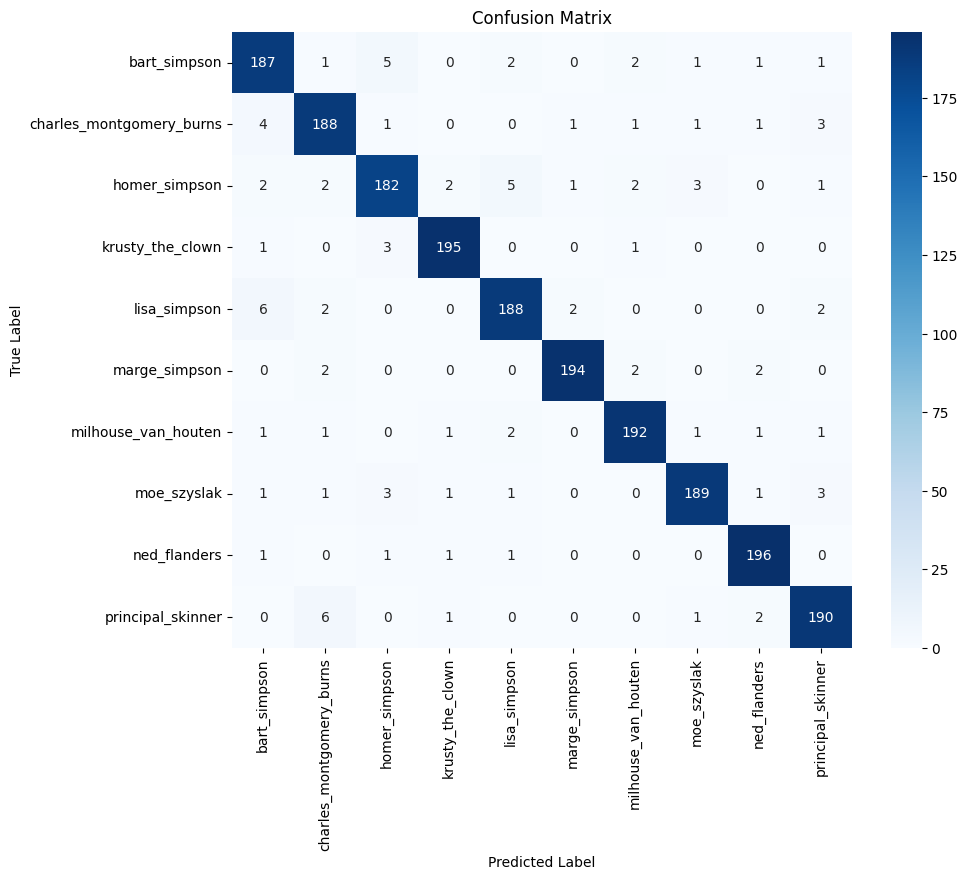

In [12]:


import cv2

def load_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image at {img_path}")
        return None
    img = img / 255.0
    return img

df_train["image_array"] = df_train["image_path"].apply(lambda x: load_image(x))
df_test["image_array"] = df_test["image_path"].apply(lambda x: load_image(x))


num_classes = df_train.label.nunique()
print(num_classes)


label_encoder = LabelEncoder()
df_train["label_encoded"] = label_encoder.fit_transform(df_train["label"])
df_test["label_encoded"] = label_encoder.transform(df_test["label"])


X_train_valid = np.stack(df_train["image_array"].values)


y_train_valid = to_categorical(df_train["label_encoded"], num_classes=num_classes)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.3, random_state=42)

X_test = np.stack(df_test["image_array"].values)
y_test = to_categorical(df_test["label_encoded"], num_classes=num_classes)

print(X_train_valid.shape)
print(y_train_valid.shape)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the target image size that the retrained model expects (e.g., 64x64)
target_size = (64, 64)

# Helper function to resize images using TensorFlow's tf.image.resize
def resize_images(images, target_size):
    return np.array([tf.image.resize(image, target_size).numpy() for image in images])

# Resize X_test if needed
X_test_resized = resize_images(X_test, target_size)

# Load the retrained model from your drive

from google.colab import drive
drive.mount('/content/drive')
import gdown

# Google Drive file ID extracted from the URL
file_id = "1-KnVuCQClJ3qoerpuL30acNPtSMmsc0C"
destination = "/content/simpsons_model.keras"  # Path where the model will be saved

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", destination, quiet=False)

import tensorflow as tf

# Load the model from the saved file
model = tf.keras.models.load_model(destination)

# Print model summary to confirm it loaded correctly
model.summary()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test, verbose=1)
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_accuracy))

# Get the model predictions for test data
predictions = model.predict(X_test_resized)
y_pred = np.argmax(predictions, axis=1)

# Convert one-hot encoded ground-truth to integer labels if necessary
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Optionally, print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
# Use label_encoder.classes_ as tick labels if available; otherwise, use default numbering.
try:
    tick_labels = label_encoder.classes_
except Exception:
    tick_labels = np.arange(cm.shape[0])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Random search model interpretability

### Occlusion test

We found that using a small occlusion size of 4 brought out focus on specific facial regions. We experimented with multiple images by changing the selected index and found that it depends on the image in question whether perturbations in the region of the face appear as impactful in the heatmap or not.

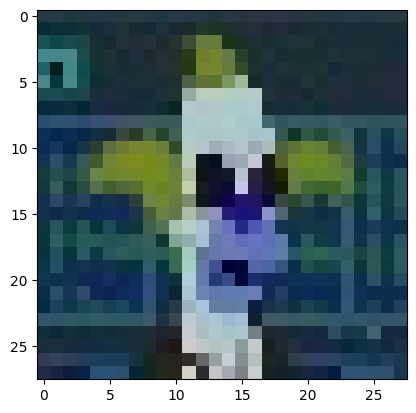

In [13]:
selected_ix = 15
test_instance = X_train[selected_ix]
plt.imshow(test_instance)

In [14]:
def occlude_image(img, pos=(0, 0), size=3, color=(0.5, 0.5, 0.5)):
    img = img.copy()
    img[pos[0] : pos[0] + size, pos[1] : pos[1] + size, :] = color
    return img

def generate_occluded_images(img, occlusion_size=3, **kwargs):
    images = []
    for y in range(0, img.shape[0] - occlusion_size + 1):
        for x in range(0, img.shape[1] - occlusion_size + 1):
            images.append(occlude_image(img, pos=(y, x), **kwargs))
    return np.array(images)



In [15]:
occlusion_size = 4
occluded_images = generate_occluded_images(test_instance, occlusion_size=occlusion_size)

In [16]:
original_pred = model.predict(np.array([test_instance]))[0]
original_prob = original_pred[np.argmax(original_pred)]
original_pred, np.argmax(original_pred), original_prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(array([3.4496759e-39, 5.3177130e-30, 5.8947124e-37, 1.0000000e+00,
        1.4477375e-40, 1.5764608e-42, 5.9420390e-35, 7.0064923e-44,
        0.0000000e+00, 2.6729348e-40], dtype=float32),
 3,
 1.0)

In [17]:
predictions = model.predict(occluded_images)
predictions.shape

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step


(625, 10)

In [18]:
all_drops = [max(0, original_prob - predictions[i, np.argmax(original_pred)]) for i in range(len(predictions))]
print("Min drop:", np.min(all_drops))
print("Max drop:", np.max(all_drops))
print("Mean drop:", np.mean(all_drops))

Min drop: 0
Max drop: 0
Mean drop: 0.0


We can observe multiple drops in probability, or not, depending on the selected image.

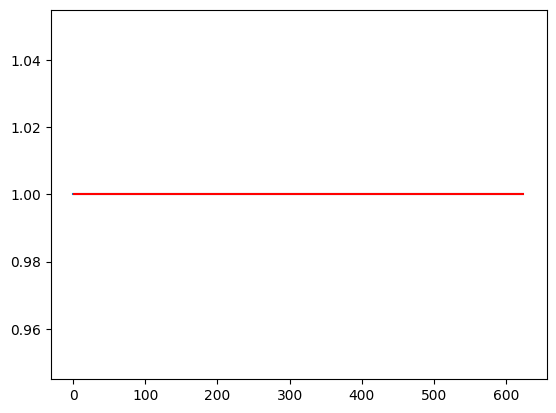

In [19]:
plt.plot(predictions[:, np.argmax(original_pred)])
plt.hlines(original_prob, xmin=0, xmax=len(predictions), colors="r")

Below an occlusion heatmap is generated for the selected image.

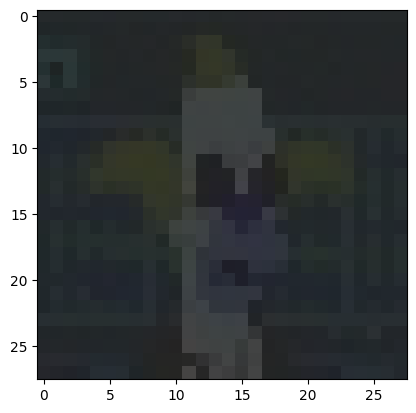

In [20]:
from sklearn.preprocessing import minmax_scale
heatmap = np.zeros(test_instance.shape)

# The assertion should be placed outside the loops
# assert pred_idx == len(occluded_images)

heatmap = np.zeros(test_instance.shape)

pred_idx = 0
for y in range(0, heatmap.shape[0] - occlusion_size + 1):
    for x in range(0, heatmap.shape[1] - occlusion_size + 1):
        probs = predictions[pred_idx, :]
        if np.argmax(probs) != np.argmax(original_pred):
            heatmap[y : y + occlusion_size, x : x + occlusion_size, :] += (1, 0, 0)
        pred_idx += 1

#Assert after the loop completes
assert pred_idx == len(occluded_images), f"pred_idx: {pred_idx}, len(occluded_images): {len(occluded_images)}"

heatmap[:, :, 0] = minmax_scale(heatmap[:, :, 0]).clip(max =1)

plt.imshow(test_instance, alpha=0.6)
plt.imshow(heatmap, alpha=0.7)

### Interpretability via dimensionality reduction through t-SNE

We focus on the last dense layer in the CNN. Dimensionality reduction from 300 to 2 dimensions via t-SNE obtains good separability between the classes.

In [23]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from sklearn.manifold import TSNE
from keras import backend as K
from keras import Model
from keras.datasets import cifar10
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D
from keras.models import Sequential
from keras.utils import to_categorical

from dl_utils import load_or_build


conv_layers = [layer.name for layer in model.layers if layer.name.startswith("conv2d")]
conv_layers


['conv2d_8',
 'conv2d_9',
 'conv2d_10',
 'conv2d_11',
 'conv2d_12',
 'conv2d_13',
 'conv2d_14',
 'conv2d_15']

In [24]:
def get_layer_output(model, layer_name):
    return Model(inputs=model.inputs, outputs=[model.get_layer(layer_name).output])

In [29]:
import tensorflow as tf
import numpy as np

# We only use the first num_images images here to keep the plot readable
num_images = 300

# Resize the images from (28, 28, 3) to (64, 64, 3)
X_train_resized = np.array([tf.image.resize(image, (64, 64)).numpy() for image in X_train[:num_images]])

# Get the activations from the layer "dense_2"
get_activations = get_layer_output(model, "dense_2")
activations = get_activations(X_train_resized)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(300, 64, 64, 3))
  warnings.warn(msg)


In [30]:
tsne = TSNE(init="pca", learning_rate=120)

In [31]:
transformed = tsne.fit_transform(activations)

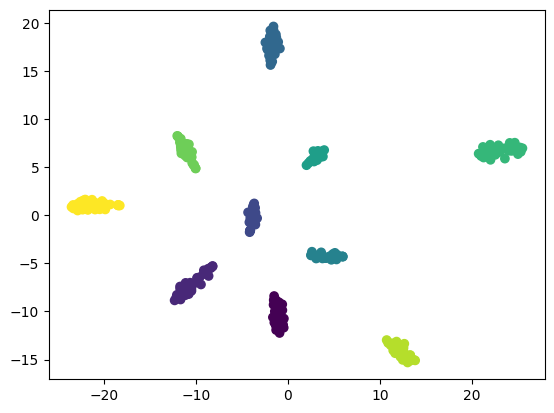

In [32]:
# Convert y_train back to categoricals so matplotlib knows what to do with it
plt.scatter(transformed[:, 0], transformed[:, 1], c=np.where(1 == y_train[:num_images])[1])

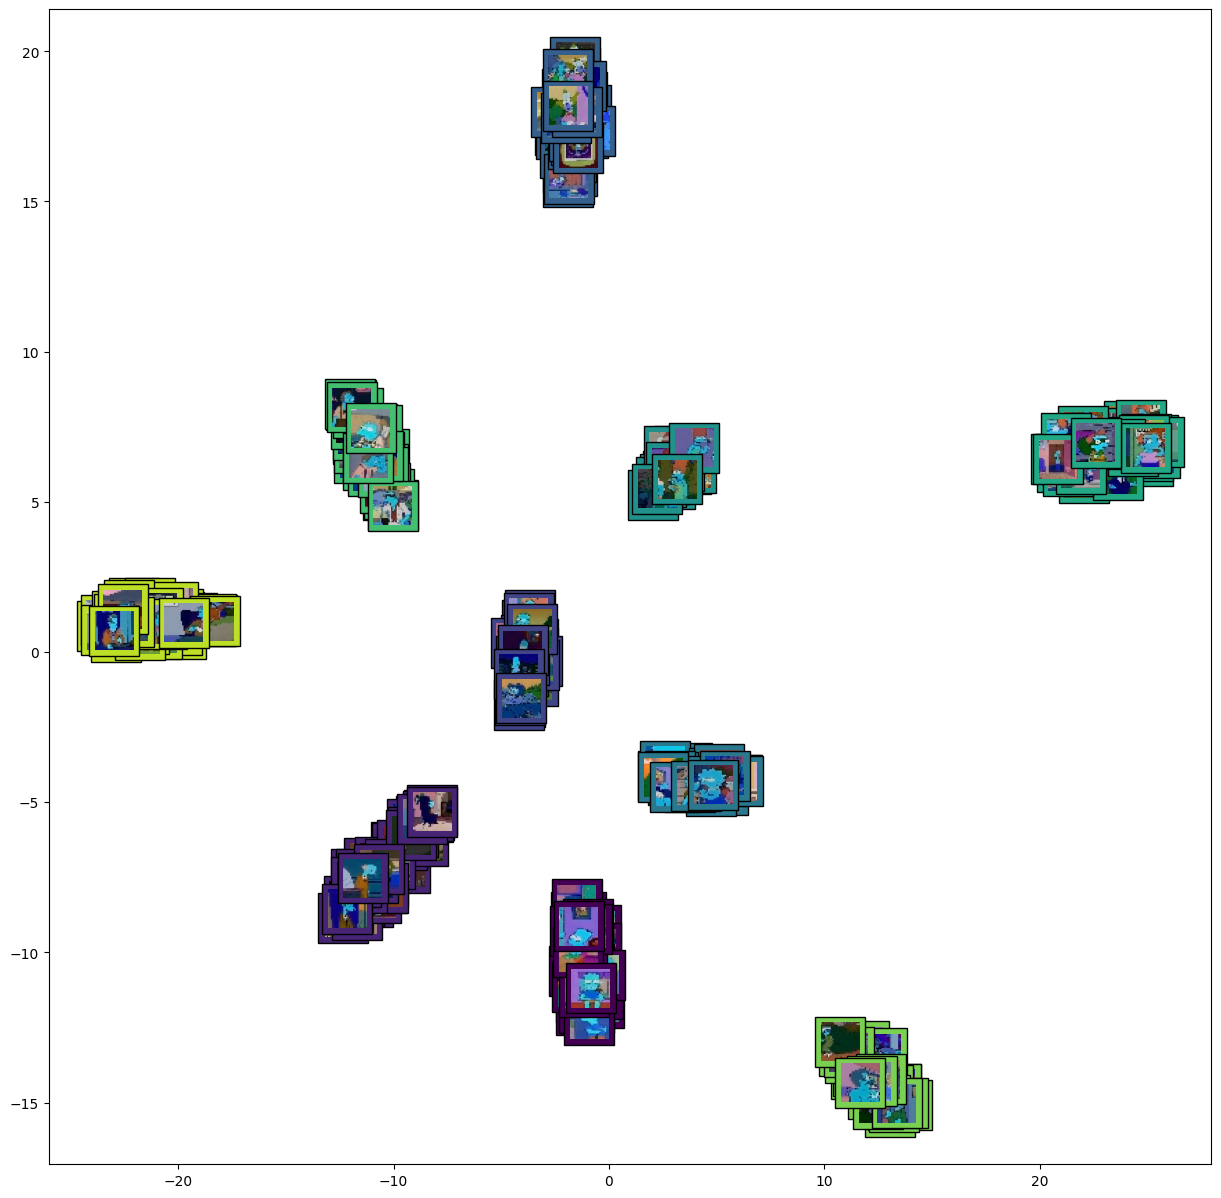

In [33]:
fig, ax = plt.subplots(figsize=(15, 15))
plt.scatter(transformed[:, 0], transformed[:, 1], c=np.where(1 == y_train[:num_images])[1])

for i, t in enumerate(transformed):
    ab = AnnotationBbox(
        OffsetImage(X_train[i]),
        (t[0], t[1]),
        bboxprops=dict(fill=True, fc=plt.get_cmap("viridis")(np.where(1 == y_train[i])[0][0] / num_classes)),
    )
    ax.add_artist(ab)

plt.show()